In [1]:
import qiskit
print(qiskit.__version__)

C:\Users\aljor\anaconda3\Lib\site-packages\qiskit\circuit\library\pauli_evolution.py:19: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  import scipy as sc


2.5.2


In [ ]:
# create a quantum circuit w 3 qubits and 2 classical bits

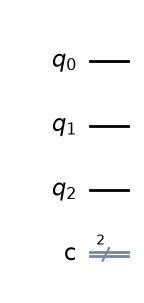

In [12]:
from qiskit import QuantumCircuit
#q0: quantum state to be teleported (Aljory)
#q1: Aljory's entangled qubit (entangled w q2)
#q2: Noura's entangled qubit (entangled w q1)
qc = QuantumCircuit(3,2)
#visualize the empty quantum circuit
qc.draw("mpl")

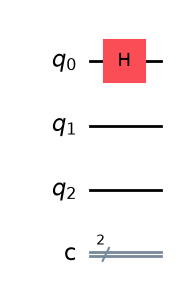

In [13]:
#prep Aljory's quantum state (Hadamard gate)
qc.h(0)
#visualize the updated circuit
qc.draw("mpl")

In [ ]:
#so q0 is the quantum information we want to teleport!

In [14]:
# next we create entanglement between q1 and q2
# q1 and q2 will form the entangled quantum connection between Aljory and Noura

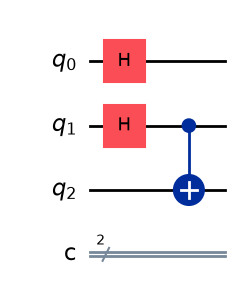

In [15]:
# put q1 into superposition (Hadamard gate)
qc.h(1)
# use q1 to control q2, creating entanglement (CNOT gate)
qc.cx(1, 2)
# visualize
qc.draw("mpl")

In [ ]:
# next we connect Aljory's quantum state (q0) to the entangled pair

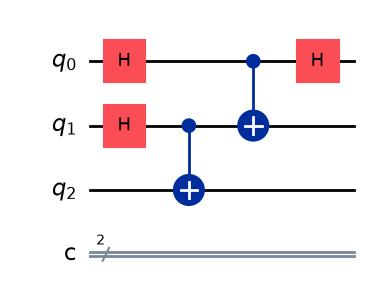

In [16]:
# use q0 to control q1 (CNOT gate)
qc.cx(0, 1)
# put q0 into superposition again (Hadamard gate)
qc.h(0)
# visualizeeee
qc.draw("mpl")

In [ ]:
#this was the part that combines the quantum information in q0 with the entangled system

In [ ]:
# now measure q0 and q1
# these measurements produce two classical bits 
# the results will be used to apply the correct operations to q2
# those two results tell us which corrections (X and/or Z) q2 needs, because one measurement result determines whether q2 needs an X gate
# ^the other measurement result determines whether q2 needs a Z gate

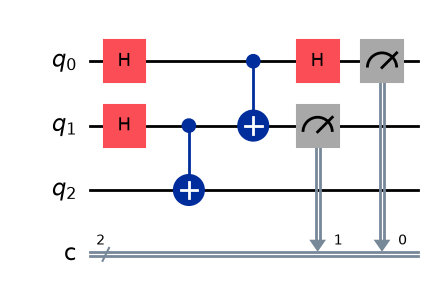

In [17]:
# qc.measure(0, 0) means measure q0 and store its result in classical bit 0
qc.measure(0, 0)
# qc.measure(1, 1) means measure q1 and store its result in classical bit 1
qc.measure(1, 1)

# visualize
qc.draw("mpl")

In [ ]:
# use Aljory's measurement results to correct Noura's qubit (correct q2)

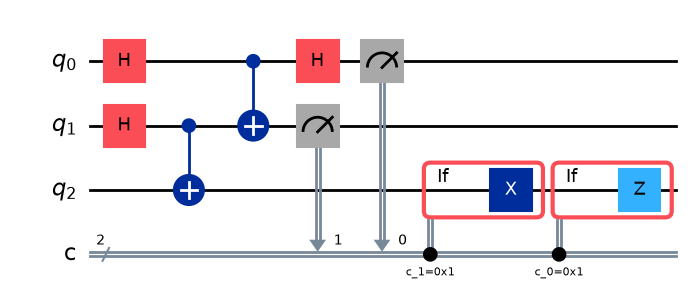

In [18]:
# if q1 measured 1, apply an X gate to q2
with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)

# if q0 measured 1, apply a Z gate to q2
with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)

# visualize the completed teleportation circuit
qc.draw("mpl")

In [ ]:
# after these corrections: q2 contains the quantum state that originally belonged to q0
# which means the same quantum information/state that q0 had at the beginning is now found on q2 at the end!!

In [ ]:
# noww lets run the circuit on a simulator
# note: AerSimulator is Qiskits local simulator for running quantum circuits

In [19]:
from qiskit_aer import AerSimulator

In [20]:
simulator = AerSimulator()

In [21]:
# run the teleportation circuit on the quantum simulator
job = simulator.run(qc)

In [22]:
result = job.result()

In [23]:
counts = result.get_counts()

print(counts)

{'10': 275, '00': 270, '11': 243, '01': 236}


In [ ]:
# our circuit ran successfully! 
# this means the 2 classical measurement results occurred roughly equally often across the simulations shots which is expected here
# we can also visualize the measurement results as a histogram:

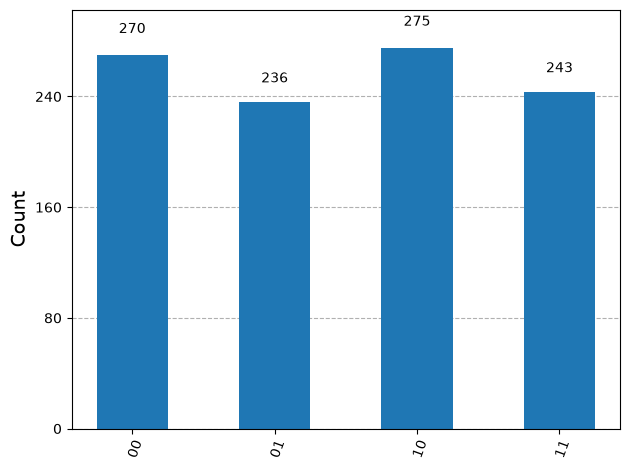

In [25]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [ ]:
#i haven't fully verified the final quantum state yet
# but thats something i can explore later. this was mainly a learning project